In [1]:
import random
import os 
import numpy
import types
import matplotlib as mpl
import sys
sys.path.insert(0, os.path.abspath("../../Adam/function-encoder"))
sys.path.insert(0, os.path.abspath("../../neuromancer/src"))
from neuromancer.modules.activations import activations
from neuromancer.system import Node, System
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer

from Datasets.get_dataset import *
from getters import load_function_encoder, get_coefficients
from Callbacks import TensorboardCallback, ProgressBarCallback, ListCallback, EvalCallback
from getters import get_policy
from Datasets.VanDerPolDataset import van_der_pol

In [2]:
args = types.SimpleNamespace(
    batch_size=32,
    num_envs=32,
    num_epochs=1,
    horizon=50,
    seed=0,
    device="cuda",
    log_dir="logs/policy",
    n_layers=4,
    n_hidden=256,
    fe_load_path="latest",
    dataset="VanDerPol", 
    policy_type="adaptive"
)

load_model = True

# Set the random seed for reproducibility
random.seed(args.seed)
numpy.random.seed(args.seed)
torch.manual_seed(args.seed)
torch.cuda.set_device(1)

In [3]:
# Fetch a dataset
dataset, _ = get_function_encoder_dataset(args)
args.fe_load_path = "logs/function_encoder/Vanderpol/seed_0/2025-10-08_19-26-22"
args.fe_load_path = "logs/function_encoder/Vanderpol/seed_0/2025-10-21_21-08-35"

print(f"Using latest function encoder model from {args.fe_load_path}")
args.log_dir = "logs/policy/VanDerPol/adaptive/seed_0/2025-10-10_18-39-47"
args.log_dir = "logs/policy/VanDerPol/adaptive/seed_0/2025-10-21_23-01-54"

# load a model, to be used as dynamics with no gradients.
model = load_function_encoder(
    load_path=args.fe_load_path,
    device=args.device,
)

model

Using latest function encoder model from logs/function_encoder/Vanderpol/seed_0/2025-10-21_21-08-35


FunctionEncoder(
  (basis_functions): BasisFunctions(
    (basis_functions): ModuleList(
      (0-10): 11 x NeuralODE(
        (ode_func): ODEFunc(
          (model): MLP(
            (activation): ReLU()
            (layers): ModuleList(
              (0): Linear(in_features=4, out_features=77, bias=True)
              (1-3): 3 x Linear(in_features=77, out_features=77, bias=True)
              (4): Linear(in_features=77, out_features=2, bias=True)
            )
          )
        )
      )
    )
  )
)

In [4]:
# get a large set of coefficients from the training dataset
coefficients, hp = get_coefficients(dataset, args, model)

# Training dataset generation
train_data, dev_data = get_trajectory_dataset(args, coefficients)

# prepare to train
train_loader = torch.utils.data.DataLoader(train_data, batch_size=args.batch_size, collate_fn=train_data.collate_fn, shuffle=False)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=args.batch_size,  collate_fn=dev_data.collate_fn, shuffle=False)

In [5]:
# create the learned dynamics model
dt = torch.tensor([[dataset.dt]], device=args.device)
def model_wrapper(x, u, c):
    ret = (
            # Function encoder expects a leading batch dimension, and a separate dt for every point.
            model((x.unsqueeze(1), u.unsqueeze(1), dt.expand(x.shape[0], 1)), coefficients=c)
            + x.unsqueeze(1)
    ).squeeze(1)
    return ret
model_node = Node(model_wrapper, ["x", "u", 'c'], ["x"], name="model")

# create the neural net control policy
policy = get_policy(args, dataset, coefficients, len(model.basis_functions.basis_functions),)

# create the closed loop system
cl_system = System([policy, model_node], nsteps=args.horizon)
objectives, constraints = train_data.get_constraints_objectives(args.device)
components = [cl_system]
loss = PenaltyLoss(objectives, constraints)
problem = Problem(components, loss)

In [6]:


# create the white box dynamics model
def wbmodel_wrapper(x, u, mu, d):
    return (
                rk4_step(van_der_pol, x, u, dt[0], mu=mu, d=d) 
                + x
    )
wbmodel_node = Node(wbmodel_wrapper, ["x", "u", 'mu', 'd'], ["x"], name="wbmodel")

# create the neural net control policy
policy = get_policy(args, dataset, coefficients, len(model.basis_functions.basis_functions),)

# create the closed loop system
cl_system_wb = System([policy, wbmodel_node], nsteps=args.horizon)
objectives, constraints = train_data.get_constraints_objectives(args.device)
components = [cl_system_wb]
loss = PenaltyLoss(objectives, constraints)
problem_wb = Problem(components, loss)

In [7]:
# create callbacks
cb1 = TensorboardCallback(args.log_dir)
cb2 = ProgressBarCallback(len(train_loader) * args.num_epochs)
cb3 = EvalCallback(dataset, dev_data, model, cb1.summary_writer)
callback = ListCallback([cb1, cb2, cb3])


optimizer = torch.optim.AdamW(policy.parameters(), lr=1e-3)
trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    optimizer=optimizer,
    epochs=args.num_epochs,
    train_metric='train_loss',
    warmup=50,
    device=args.device,
    callback=callback
)

if problem_wb is not None:
    # create a trainer for the white box model
    wb_trainer = Trainer(
        problem_wb,
        train_loader,
        dev_loader,
        optimizer=optimizer,
        epochs=args.num_epochs,
        train_metric='train_loss',
        warmup=50,
        device=args.device,
        callback=callback
    )

if not load_model:
    # train the policy
    best_model = trainer.train()

    # save the policy
    os.makedirs(args.log_dir, exist_ok=True)
    trainer.model.load_state_dict(best_model)
    torch.save(trainer.model.state_dict(), os.path.join(args.log_dir, "policy.pth"))
else:
    # load the policy
    
    trainer.model.load_state_dict(torch.load(os.path.join(args.log_dir, "policy.pth")))
    # trainer.model.load_state_dict(torch.load(os.path.join(args.log_dir, "model_epoch_5.pth")))
    
    if problem_wb is not None:
        wb_trainer.model.load_state_dict(torch.load(os.path.join(args.log_dir, "policy.pth")))
        # wb_trainer.model.load_state_dict(torch.load(os.path.join(args.log_dir, "model_epoch_5.pth")))

Training...:   0%|          | 0/32 [00:00<?, ?it/s]

Testing Closed Loop System...
Plotting trajectory for closed loop system with white box model...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

0 0.21291726698637053 [-0.20190704  0.06671667] -1.3425320753679844
1 0.2295184114683251 [-0.2019254 -0.067527 ] -0.5266543614749063
2 0.23052649847052395 [-0.19231099 -0.12528043] -0.12997709771457336
3 0.22085864829216986 [-0.17878023 -0.14553383] 0.05715672613430644
4 0.20614341551997853 [-0.16411558 -0.14779925] 0.1399974557861485
5 0.18968948488668905 [-0.14963417 -0.14179112] 0.17136783257243246
6 0.1731922448346867 [-0.13592533 -0.13231178] 0.17775284951972958
7 0.15745048776018744 [-0.12322    -0.121706

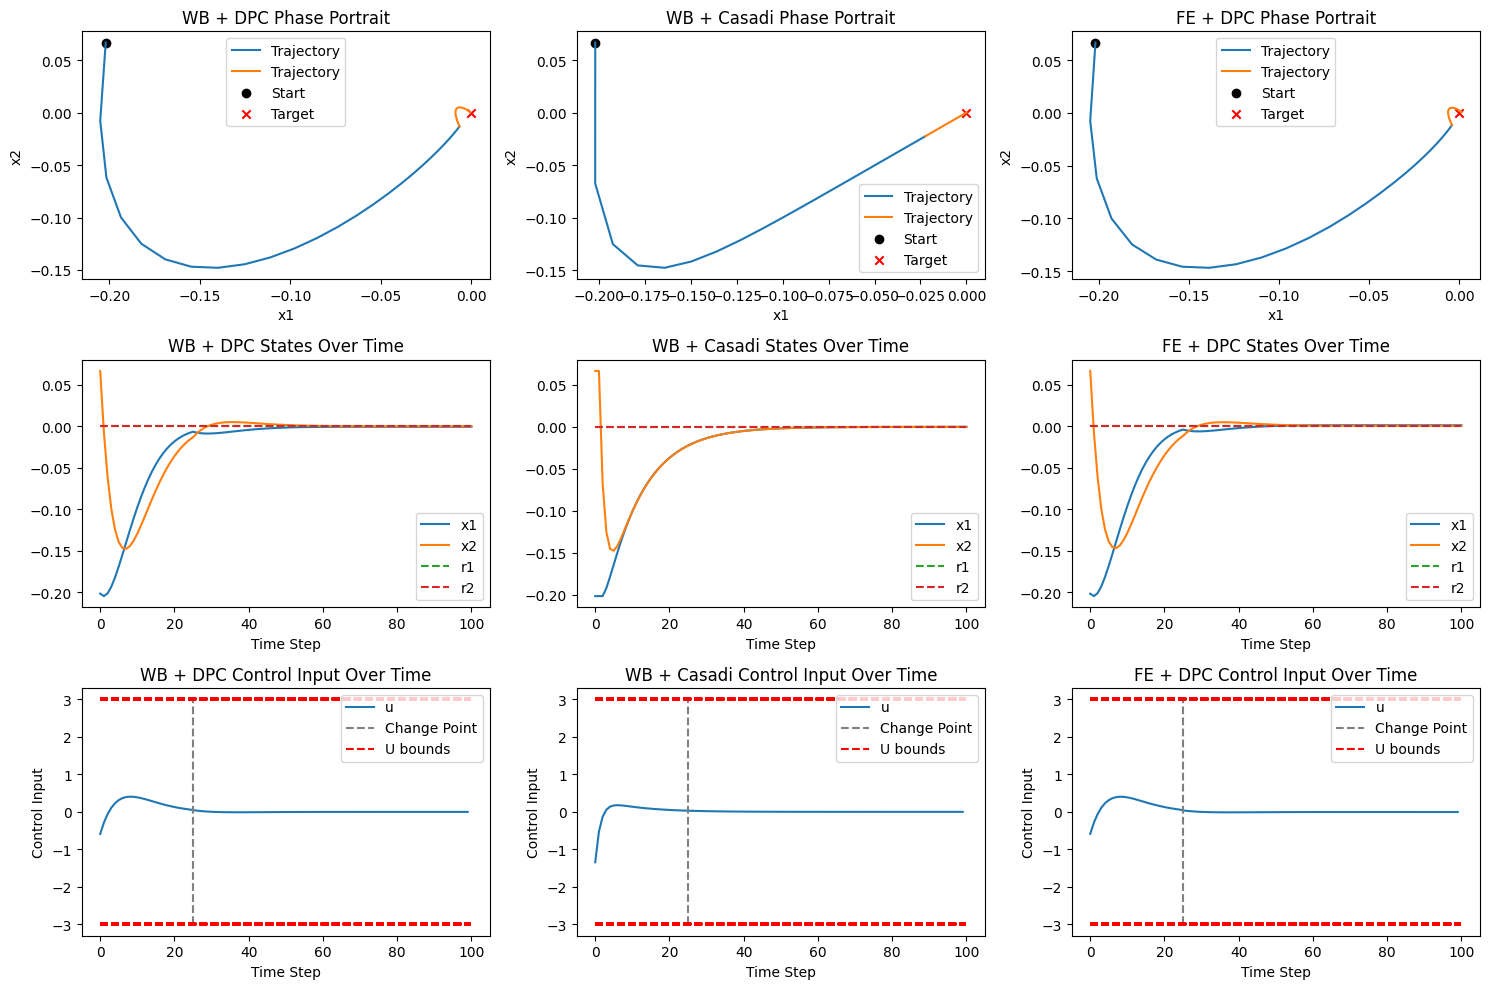

Function Encoder DPC computation time: 0.549267 s
White Box DPC computation time: 0.074869 s
Casadi MPC computation time: 1.199883 s


In [8]:
# plot the closed loop trajectories in the simulated system.
mu = hp["mu"].to(args.device)
d = hp["d"].to(args.device)

casadi_plot = True
with torch.no_grad():
    for i in range(1):
        if casadi_plot:
            R_fe_dpc, Y_fe_dpc, U_fe_dpc, Y_wb_dpc, U_wb_dpc, Y_wb_casadi, U_wb_casadi, hp_trajectory, split_point = train_data.plot_trajectory(coefficients, cl_system, args.log_dir, wb_cl_system=cl_system_wb, hp=hp, casadi_plot=casadi_plot)
        else:
            R_fe_dpc, Y_fe_dpc, U_fe_dpc, Y_wb_dpc, U_wb_dpc, hp_trajectory, split_point = train_data.plot_trajectory(coefficients, cl_system, args.log_dir, wb_cl_system=cl_system_wb, hp=hp, casadi_plot=casadi_plot)


In [9]:
import pandas as pd

def mse_loss(a, b):
    return torch.mean((a - b) ** 2).item()

# Convert numpy arrays to torch tensors for loss calculation
Y_wb_casadi_tensor = torch.from_numpy(Y_wb_casadi.T).to(R_fe_dpc.device)

loss_fe_dpc = mse_loss(R_fe_dpc, Y_fe_dpc)
loss_wb_dpc = mse_loss(R_fe_dpc, Y_wb_dpc)
loss_wb_casadi = mse_loss(R_fe_dpc, Y_wb_casadi_tensor)


loss_table = pd.DataFrame({
    "Reference": ["Reference vs Y_fe_dpc", "Reference vs Y_wb_dpc", "Reference vs Y_wb_casadi"],
    "MSE Loss": [loss_fe_dpc, loss_wb_dpc, loss_wb_casadi]
})

print(loss_table)

                  Reference  MSE Loss
0     Reference vs Y_fe_dpc  0.002683
1     Reference vs Y_wb_dpc  0.002725
2  Reference vs Y_wb_casadi  0.002653


In [10]:
# generate initial data for closed loop simulation
nsteps = 100
state_bounds = train_data.initial_state_bounds.to(coefficients.device)
initial_state = torch.rand(1, 1, train_data.state_size, device=coefficients.device) * (state_bounds[1] - state_bounds[0]) + state_bounds[0]
R_orig = torch.zeros(1, nsteps + 1, train_data.state_size).to(coefficients.device)  # reference trajectory

def integrate_uncontrolled_system(starting_c, starting_mu, starting_d, _dt, n, initial_state, split_point=None, ending_c=None, ending_mu=None, ending_d=None):
    
    # Integrate the true trajectory
    coefficients = starting_c
    mu = starting_mu
    d = starting_d
    x = initial_state.clone()
    u = torch.zeros((1, 1), device=args.device)
    y = [x]
    for k in range(n):
        if split_point is not None and k >= split_point and ending_c is not None:
            coefficients = ending_c
            mu = ending_mu
            d = ending_d
        x = rk4_step(van_der_pol, x, u, _dt, mu=mu, d=d) + x
        y.append(x)
    y = torch.cat(y, dim=0)
    y = y.detach().cpu().numpy()

    # Integrate the predicted trajectory
    coefficients = starting_c
    mu = starting_mu    
    d = starting_d
    x = initial_state.clone()
    u = torch.zeros((1, 1, 1), device=args.device)
    x = x.unsqueeze(1)
    _dt = _dt.unsqueeze(0)
    pred = [x]
    for k in range(n):
        if split_point is not None and k >= split_point and ending_c is not None:
            coefficients = ending_c
            mu = ending_mu
            d = ending_d
        x = model((x, u, _dt), coefficients=coefficients.unsqueeze(0)) + x
        pred.append(x)
    pred = torch.cat(pred, dim=1)
    pred = pred.detach().cpu().numpy()

    return y, pred


def _plot_trajectory(Y, R, U, Umin, Umax, nsteps, ax, split_point):
    terminal_time_plot = 75
    if split_point is not None:
        ax.set_xlabel("Time steps")
        ax.plot(Y[:terminal_time_plot, 0])
        ax.plot(Y[:terminal_time_plot, 1])
        ax.plot(U[:terminal_time_plot])
        min_point = min(U[:terminal_time_plot].min(), Y[:terminal_time_plot, 0].min(), Y[:terminal_time_plot, 1].min())
        max_point = max(U[:terminal_time_plot].max(), Y[:terminal_time_plot, 0].max(), Y[:terminal_time_plot, 1].max())
        ax.vlines(split_point-1, min_point, max_point, colors='purple', linestyles='dashed', label='Switch time', linewidth=1)
        ax.plot(R[:terminal_time_plot, 0], '--', color='gray')
    else:
        ax.set_title(f"Stabilizing control")
        ax.plot(Y[:terminal_time_plot, 0], label="x1")
        ax.plot(Y[:terminal_time_plot, 1], label="x2")
        ax.plot(U[:terminal_time_plot], label="u")
        ax.plot(R[:terminal_time_plot, 0], '--', color='gray', label='ref')
        ax.set_xlabel("Time steps")


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman


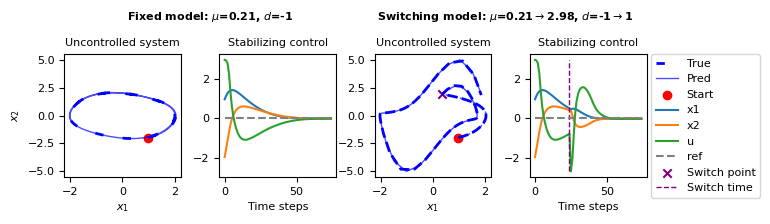

In [11]:
# First plot uncontrolled system without changing parameters
# Second plot control of the same system
# Third plot uncontrolled system with changing parameters
# Fourth plot control of the same system with changing parameters

# generate initial data for closed loop simulation
nsteps = 107
state_bounds = train_data.initial_state_bounds.to(coefficients.device)
# initial_state = torch.rand(1, 1, train_data.state_size, device=coefficients.device) * (state_bounds[1] - state_bounds[0]) + state_bounds[0]
initial_state = torch.tensor([[[0.98, -1.97]]], device=coefficients.device)
R_orig = torch.zeros(1, nsteps + 1, train_data.state_size).to(coefficients.device)  # reference trajectory

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 8,  
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.titlesize": 8,
})

mus = hp["mu"].cpu().numpy()
ds = hp["d"].cpu().numpy()

neg_indices = np.where(ds.ravel() == -1)[0]
default_index = int(neg_indices[np.argmin(mus.ravel()[neg_indices])])
pos_inds = np.where(ds.ravel() == 1)[0]
hp_index = int(pos_inds[np.argmax(mus.ravel()[pos_inds])])

# constraints bounds
Umin = train_data.action_bounds[0].unsqueeze(0).expand(nsteps, 1).cpu()
Umax = train_data.action_bounds[1].unsqueeze(0).expand(nsteps, 1).cpu()

s = train_data.dt  # Time step for simulation
_dt = torch.tensor([s], device=args.device)

fig, ax = plt.subplots(1, 4, figsize=(6.5, 2))


# Get the bounding boxes (in figure coordinates)
fig.canvas.draw()  # make sure positions are updated
b1 = ax[0].get_position()
b2 = ax[1].get_position()
b3 = ax[2].get_position()
b4 = ax[3].get_position()

ax = ax.reshape(2, 2)
# Compute midpoints for first two and last two subplots
x12 = (b1.x0 + b2.x1) / 2
x34 = (b3.x0 + b4.x1) / 2 + 0.05
y_top = max(b1.y1, b2.y1, b3.y1, b4.y1) + 0.1

# Add centered overlay text
fig.text(x12, y_top + 0.03, r"Fixed model: $\mu$=0.21, $d$=-1",
         ha='center', va='bottom', fontsize=8, fontweight='bold')
fig.text(x34, y_top + 0.03, r"Switching model: $\mu$=0.21$\rightarrow$2.98, $d$=-1$\rightarrow$1",
         ha='center', va='bottom', fontsize=8, fontweight='bold')

# share y axes for the state plots
ax[1, 0].sharex(ax[0, 0])
ax[1, 0].sharey(ax[0, 0])
ax[1, 1].sharex(ax[0, 1])
ax[1, 1].sharey(ax[0, 1])

theta = np.linspace(0, 2*np.pi, 200)
x1 = 2*np.cos(theta)
x2 = np.sin(theta)

# first plot
coefficients_s = coefficients[default_index].to(args.device)
mu = hp["mu"][default_index].to(args.device)
d = hp["d"][default_index].to(args.device)
y, pred = integrate_uncontrolled_system(coefficients_s, mu, d, _dt, nsteps, initial_state.squeeze(0))

ax[0, 0].plot(y[:, 0], y[:, 1], label="True", linewidth=2, linestyle='--', color='blue' , dashes=(3,7))
ax[0, 0].plot(pred[0, :, 0], pred[0, :, 1], label="Pred", linewidth=1, color='blue', alpha=0.7)
ax[0, 0].scatter(y[0, 0], y[0, 1], color='red', label="Start", marker='o')
ax[0, 0].set_xlabel(r'$x_1$')
ax[0, 0].set_ylabel(r'$x_2$')
ax[0, 0].set_title(f"Uncontrolled system")  


# second plot
coefficients_s = coefficients[default_index:default_index+1].unsqueeze(0).repeat(1, nsteps + 1, 1) # repeat coefficients for each time step
mu = hp["mu"].to(coefficients.device)[default_index:default_index+1].unsqueeze(0).repeat(1, nsteps + 1, 1) if hp.get("mu") is not None else None
d = hp["d"].to(coefficients.device)[default_index:default_index+1].unsqueeze(0).repeat(1, nsteps + 1, 1) if hp.get("d") is not None else None
dev_dict = {
    "x": initial_state,
    "r": R_orig,
    "c": coefficients_s,
    'mu': mu,
    'd': d
}

# perform closed-loop simulation
cl_system.nsteps = nsteps
trajectories = cl_system(dev_dict)

# plot closed loop trajectory
Y_fe_dpc = trajectories['x'].detach().cpu().reshape(nsteps + 1, train_data.state_size)
R_fe_dpc = trajectories['r'].detach().cpu().reshape(nsteps + 1, train_data.state_size)
U_fe_dpc = trajectories['u'].detach().cpu().reshape(nsteps, train_data.action_size)

_plot_trajectory(Y_fe_dpc, R_fe_dpc, U_fe_dpc, Umin, Umax, nsteps, ax=ax[0, 1], split_point=None)

# third plot
split_point = 25
indices = torch.zeros(nsteps + 1, dtype=torch.long)
indices[:split_point] = default_index  # use default (lowest mu) for first part
indices[split_point:] = hp_index       # use hp_index (largest mu) for the rest

# Prepare coefficients and hidden parameters for each time step
starting_c = coefficients[default_index]
starting_mu = hp["mu"].to(coefficients.device)[default_index]
starting_d = hp["d"].to(coefficients.device)[default_index]
ending_c = coefficients[hp_index]
ending_mu = hp["mu"].to(coefficients.device)[hp_index]
ending_d = hp["d"].to(coefficients.device)[hp_index]

y, pred = integrate_uncontrolled_system(starting_c, starting_mu, starting_d, _dt, nsteps, initial_state.squeeze(0), split_point=split_point, ending_c=ending_c, ending_mu=ending_mu, ending_d=ending_d)
ax[1, 0].scatter(y[0, 0], y[0, 1], color='red', marker='o')

ax[1, 0].plot(y[:split_point+1, 0], y[:split_point+1, 1], color='blue', linestyle='--', linewidth=2, zorder=2, ) #dashes=(1,3)
ax[1, 0].plot(pred[0, :split_point+1, 0], pred[0, :split_point+1, 1], color='blue', linestyle='--', linewidth=1, zorder=5, alpha=0.7)
ax[1, 0].plot(y[split_point:, 0], y[split_point:, 1], color='blue', linestyle='--', linewidth=2, zorder=2, ) #, label='True' dashes=(1,3)
ax[1, 0].plot(pred[0, split_point:, 0], pred[0, split_point:, 1], color='blue', linewidth=1, zorder=5, alpha=0.7) #, label='Pred'
ax[1, 0].scatter(y[split_point, 0], y[split_point, 1], color='purple', marker='x', label='Switch point')

ax[1, 0].set_xlabel(r"$x_{1}$")
ax[1, 0].set_title(f"Uncontrolled system")

# fourth plot
indices = torch.zeros(nsteps + 1, dtype=torch.long)
indices[:split_point] = default_index  # use default (lowest mu) for first part
indices[split_point:] = hp_index       # use hp_index (largest mu) for the rest

# # Prepare coefficients and hidden parameters for each time step
coefficients_s = coefficients[indices].unsqueeze(0) 
mu = hp["mu"].to(coefficients.device)[indices].unsqueeze(0) 
d = hp["d"].to(coefficients.device)[indices].unsqueeze(0)

dev_dict = {
    "x": initial_state,
    "r": R_orig,
    "c": coefficients_s,
    'mu': mu,
    'd': d
}

# perform closed-loop simulation
cl_system.nsteps = nsteps
trajectories = cl_system(dev_dict)

# plot closed loop trajectory
Y_fe_dpc = trajectories['x'].detach().cpu().reshape(nsteps + 1, train_data.state_size)
R_fe_dpc = trajectories['r'].detach().cpu().reshape(nsteps + 1, train_data.state_size)
U_fe_dpc = trajectories['u'].detach().cpu().reshape(nsteps, train_data.action_size)

_plot_trajectory(Y_fe_dpc, R_fe_dpc, U_fe_dpc, Umin, Umax, nsteps, ax=ax[1, 1], split_point=split_point)
ax[1, 1].set_title(f"Stabilizing control")

handles, labels = [], []
for a in ax.flatten():
    h, l = a.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

leg = fig.legend(
    by_label.values(),
    by_label.keys(),
    loc='center left',
    frameon=True,        
    fontsize=8,
    bbox_to_anchor=(0.98, 0.5)  
)
plt.subplots_adjust(
    wspace=0.25,  
    hspace=0.4   
)
for text in leg.get_texts():
    text.set_ha('right') 
plt.tight_layout()
plt.savefig(args.log_dir + "/vpd_cl_trajectory.pdf", format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [12]:
args.log_dir

'logs/policy/VanDerPol/adaptive/seed_0/2025-10-21_23-01-54'